<a href="https://colab.research.google.com/github/AmandaThenuwara/SE4050-Facial-Emotion-Recognition/blob/feat%2Ftrain-a-model-using-CNN/notebooks/cnn/IT23175266_CNN_FER2013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Emotion Recognition — Custom CNN

**Module:** SE4050 — Deep Learning
**Author:** Charuka Shashintha Wijesundara
**Model:** Custom Convolutional Neural Network (CNN)

## Objective
Develop and evaluate a custom CNN that classifies facial images into
seven expression categories: angry, disgust, fear, happy, neutral,
sad, and surprise.

## Dataset
FER-2013: https://www.kaggle.com/datasets/msambare/fer2013

The dataset contains 48×48 grayscale facial images.

## Experimental Setup
- Split seed: 42
- Validation split: 20% of the supplied training folder
- Split method: Keras image_dataset_from_directory
- Class order: angry, disgust, fear, happy, neutral, sad, surprise
- Use training and validation data for model development and tuning.
- Reserve the supplied test folder for final model evaluation.
- Verify identical training/validation file membership across the group.

In [4]:
from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/archive.zip")

assert ZIP_PATH.is_file(), "archive.zip was not found."
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024**2):.2f} MiB")

# Check every archived file for corruption before extracting.
with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    bad_file = archive.testzip()
    assert bad_file is None, f"Corrupted file: {bad_file}"

print("ZIP check passed — no corrupted files found.")

ZIP size: 60.32 MiB
ZIP check passed — no corrupted files found.


In [5]:
# Extract the verified ZIP into Colab's local storage.
DATA_DIR = Path("/content/fer2013")

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(DATA_DIR)

print("Extraction complete.")
print("Top-level folders:")
for folder in sorted(DATA_DIR.iterdir()):
    if folder.is_dir():
        print(folder.name)

Extraction complete.
Top-level folders:
test
train


In [6]:
TRAIN_DIR = DATA_DIR / "train"

CLASS_NAMES = [
    "angry", "disgust", "fear", "happy",
    "neutral", "sad", "surprise"
]

# Confirm the training folders match our expected classes.
found_classes = sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir())
assert found_classes == CLASS_NAMES, f"Unexpected classes: {found_classes}"

# Count images in each training class.
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
train_counts = {}

for emotion in CLASS_NAMES:
    count = sum(
        1 for p in (TRAIN_DIR / emotion).rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    )
    train_counts[emotion] = count
    print(f"{emotion:10s}: {count:,}")

print(f"\nTotal training-folder images: {sum(train_counts.values()):,}")

angry     : 3,995
disgust   : 436
fear      : 4,097
happy     : 7,215
neutral   : 4,965
sad       : 4,830
surprise  : 3,171

Total training-folder images: 28,709


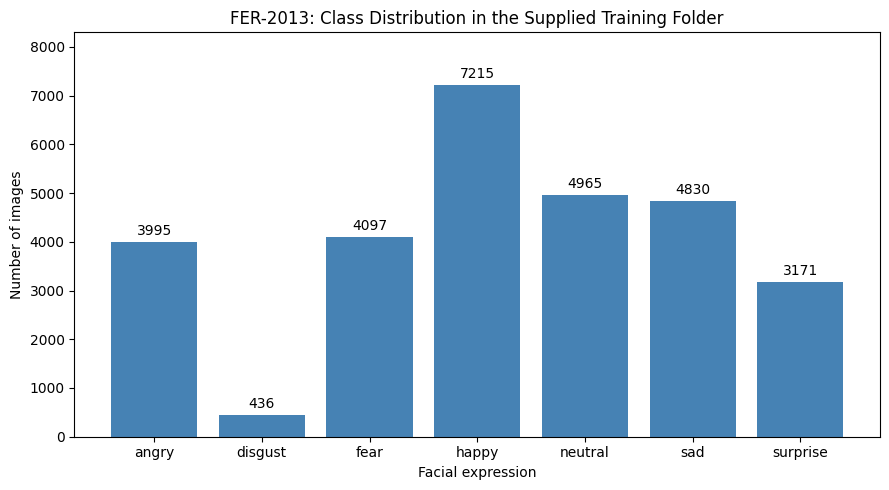

In [7]:
import matplotlib.pyplot as plt

# Visualize class counts before the train/validation split.
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    CLASS_NAMES,
    [train_counts[name] for name in CLASS_NAMES],
    color="steelblue"
)

ax.bar_label(bars, padding=3)
ax.set_title("FER-2013: Class Distribution in the Supplied Training Folder")
ax.set_xlabel("Facial expression")
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(train_counts.values()) * 1.15)

plt.tight_layout()
plt.show()

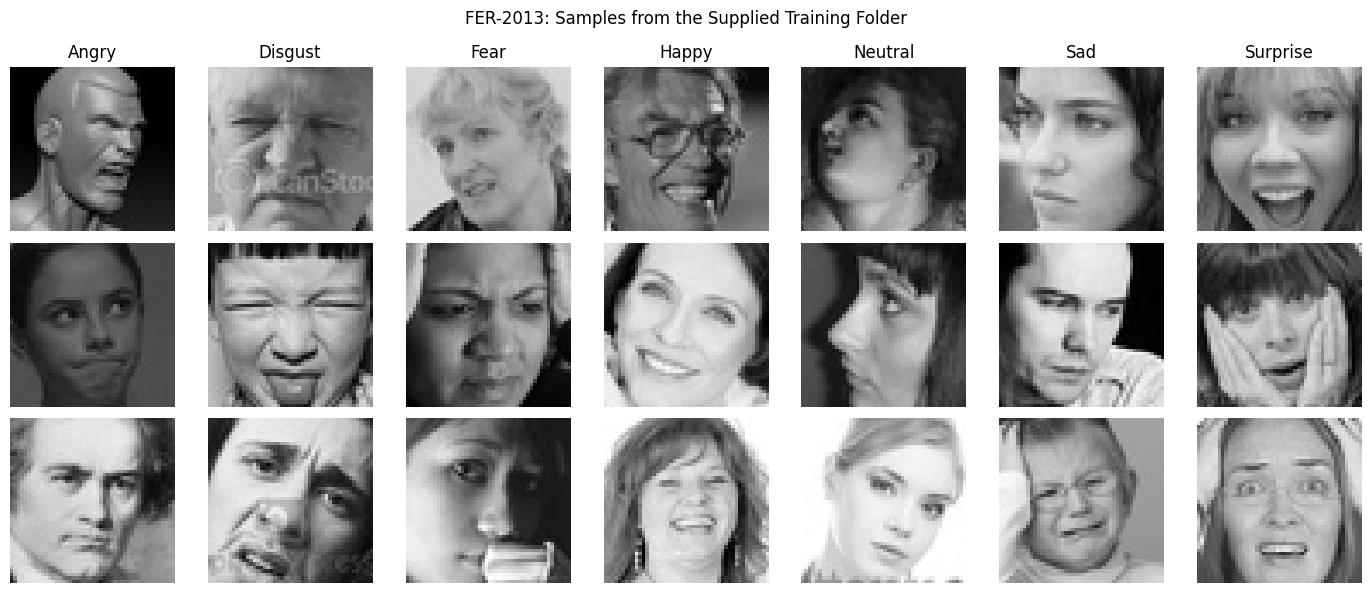

In [8]:
from PIL import Image
import random

# A fixed seed makes the sample selection repeatable.
sample_rng = random.Random(42)

fig, axes = plt.subplots(3, 7, figsize=(14, 6))

for col, emotion in enumerate(CLASS_NAMES):
    image_paths = sorted(
        p for p in (TRAIN_DIR / emotion).rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    )

    for row, image_path in enumerate(sample_rng.sample(image_paths, 3)):
        with Image.open(image_path) as image:
            axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=255)

        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(emotion.capitalize())

fig.suptitle("FER-2013: Samples from the Supplied Training Folder")
plt.tight_layout()
plt.show()

In [9]:
from collections import Counter

size_counts = Counter()
mode_counts = Counter()
unreadable_files = []

# Inspect all images in the supplied training folder.
for emotion in CLASS_NAMES:
    for image_path in sorted((TRAIN_DIR / emotion).rglob("*")):
        if not image_path.is_file():
            continue
        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            with Image.open(image_path) as image:
                image.load()  # Confirm the image can be decoded.
                size_counts[image.size] += 1
                mode_counts[image.mode] += 1
        except Exception as error:
            unreadable_files.append((str(image_path), str(error)))

print("Image dimensions:", dict(size_counts))
print("Image modes:", dict(mode_counts))
print("Unreadable images:", len(unreadable_files))

if unreadable_files:
    print("First few errors:", unreadable_files[:5])

Image dimensions: {(48, 48): 28709}
Image modes: {'L': 28709}
Unreadable images: 0


## Initial Dataset Observations

- The supplied training folder contains 28,709 images across seven expression classes.
- All inspected training-folder images are 48×48 pixels in 8-bit grayscale format.
- No unreadable images were found in the supplied training folder.
- The classes are imbalanced: happy contains 7,215 images, while disgust contains only 436.
- This imbalance makes accuracy alone insufficient. Evaluation will include macro F1 and per-class precision and recall.
- The displayed samples vary in lighting, face angle, and image clarity, which may make classification more difficult.
- These observations describe the supplied training folder before the training/validation split.
- The supplied test folder has not been used for exploratory analysis or model development.

## Running This Notebook So Far

1. Download the linked FER-2013 dataset from Kaggle.
2. Upload archive.zip using Colab's Files panel so it is available at /content/archive.zip.
3. Run the code cells in order to verify, extract, and inspect the training data.
4. If Colab's temporary runtime storage is cleared, upload the ZIP again and rerun the cells.

Model training and final test evaluation have not been performed yet.